In [ ]:
import os, sys
from pathlib import Path


PROJECT_ROOT = Path("/home/mame_hil")
os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))

os.makedirs("output/ana", exist_ok=True)

from abx_app.AttackCNN.generate_image_from_condition import generate_image_from_condition
import torch
import torchvision.transforms as transforms
from abx_app.AttackCNN.utils.condition import Condition, AttackParamsLoader
from abx_app.AttackCNN.utils.model_utils import load_model
from abx_app.AttackCNN.utils.data_utils import prepare_data_from_pool

import numpy as np
import matplotlib.pyplot as plt
import random
from matplotlib.lines import Line2D
import cv2

# check path
print("config_attackcnn.yaml exists:", Path("config_attackcnn.yaml").exists())
print("model exists:", Path("data/models/imagenet_l2_3_0.pt").exists())

config_attackcnn.yaml exists: True
model exists: True


In [50]:
# model setting
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = load_model(device)
transform = transforms.Compose(
    [
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
    ]
)

data_loader = prepare_data_from_pool(1, transform, device, example=True) # dog (example)

## Load subject data

In [ ]:
import csv
from collections import defaultdict

selected_subject = "Overall"  # e.g. "s00", "s01", ..., "Overall"
threshold_csv_path = Path("notebooks/output/ana/subject_layer_thresholds_jupyter.csv")

def load_subject_thresholds(csv_path, subject):
    thresholds_by_layer = defaultdict(dict)
    available_subjects = set()
    with csv_path.open(encoding="utf-8-sig", newline="") as f:
        reader = csv.DictReader(f)
        for row in reader:
            available_subjects.add(row["Subject"])
            if row["Subject"] != subject:
                continue
            thresholds_by_layer[row["Layer"]][int(row["Eccentricity"])] = float(row["Mean Threshold"])
    if not thresholds_by_layer:
        raise ValueError(
            f"Subject '{subject}' was not found in {csv_path}. Available: {sorted(available_subjects)}"
        )
    return dict(thresholds_by_layer)

subject_thresholds = load_subject_thresholds(threshold_csv_path, selected_subject)

## Generate perturbed images

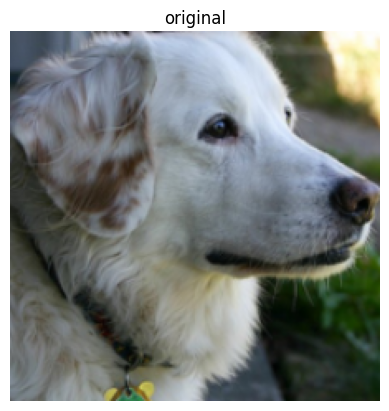

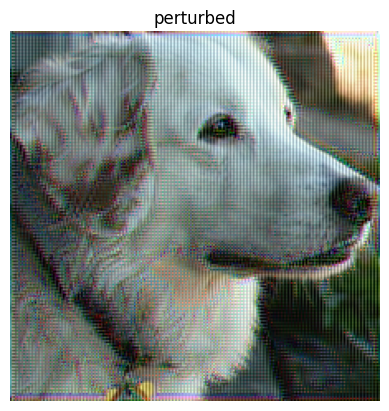

In [58]:
# generation example: conv1, comp0, plus, t=55
cond = Condition(
    ecc=4,
    mode="ica",
    layer="conv1",
    component=0,
    direction="plus",
)

handler = cond.get_decomposition_handler()
params_loader = AttackParamsLoader()
attack_params = params_loader.get_attack_params(cond, 55)


results = generate_image_from_condition(
    attack_params=attack_params,
    cond=cond,
    model=model,
    device=device,
    data_loader_origin=data_loader,
    handler=handler,
    value=55,
    layer1_name="conv1",
)

orig_img = np.clip(results[0].original_image[0].squeeze().transpose((1, 2, 0)), 0, 1)
fake_img = np.clip(results[0].perturbed_images[-1].squeeze().transpose((1, 2, 0)), 0, 1)

plt.imshow(orig_img)
plt.axis("off")
plt.title("original")
plt.show()

plt.imshow(fake_img)
plt.axis("off")
plt.title("perturbed")
plt.show()

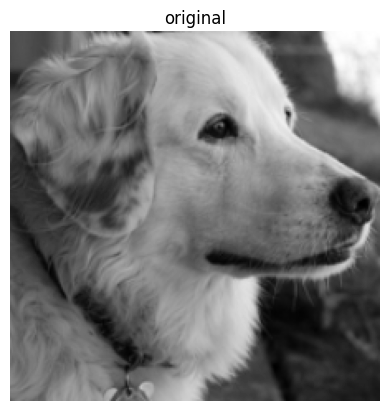

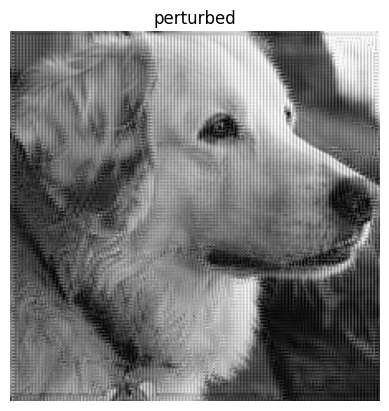

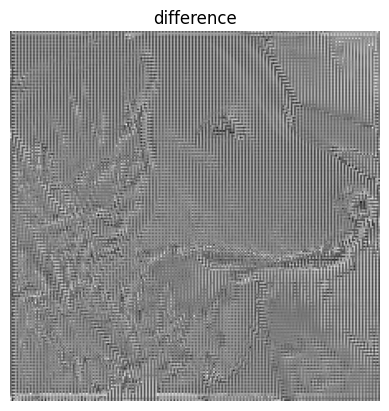

In [61]:
# grayscale
def rgb_to_grayscale(image):
    return np.dot(image[..., :3], [0.2126, 0.7152, 0.0722])

orig_gray = rgb_to_grayscale(orig_img)
fake_gray = rgb_to_grayscale(fake_img)
diff_img = orig_gray - fake_gray

plt.imshow(orig_gray, cmap="gray")
plt.axis("off")
plt.title("original")
plt.show()

plt.imshow(fake_gray, cmap="gray")
plt.axis("off")
plt.title("perturbed")
plt.show()

plt.imshow(diff_img, cmap="gray")
plt.axis("off")
plt.title("difference")
plt.show()

In [33]:
# fig6(a)
def generate_images(layers_and_thresholds, model, device, transform):
    generated_results = {}
    for cond_layer, threshold in layers_and_thresholds.items():
        cond = Condition(
            ecc=4,
            mode="ica",
            layer=cond_layer,
            component=0,
            direction="plus",
        )

        handler = cond.get_decomposition_handler()
        params_loader = AttackParamsLoader()
        attack_params = params_loader.get_attack_params(cond, threshold)
        data_loader = prepare_data_from_pool(1, transform, device, example=True)

        results = generate_image_from_condition(
            attack_params=attack_params,
            cond=cond,
            model=model,
            device=device,
            data_loader_origin=data_loader,
            handler=handler,
            value=threshold,
            layer1_name="conv1",
        )

        generated_results[cond_layer] = results[0]
    return generated_results

def plot_combined_diff_images(generated_results):
    fig_diff, axes_diff = plt.subplots(len(generated_results), 3, figsize=(15 + 2, 5 * len(generated_results) + 2))
    for idx, (cond_layer, result) in enumerate(generated_results.items()):
        orig_img = np.clip(result.original_image[0].squeeze().transpose((1, 2, 0)), 0, 1)
        fake_img = np.clip(result.perturbed_images[-1].squeeze().transpose((1, 2, 0)), 0, 1)

        orig_gray = rgb_to_grayscale(orig_img)
        fake_gray = rgb_to_grayscale(fake_img)
        diff_img = orig_gray - fake_gray

        if idx == 0:
            fig_diff.subplots_adjust(left=0.2)
        axes_diff[idx, 0].text(
            -0.05,
            0.5,
            f"{cond_layer} (t={layers_and_thresholds[cond_layer]})",
            fontsize=36,
            va="center",
            ha="right",
            rotation=90,
            transform=axes_diff[idx, 0].transAxes,
        )

        axes_diff[idx, 0].imshow(orig_gray, cmap="gray"); axes_diff[idx, 0].axis("off")
        axes_diff[idx, 1].imshow(fake_gray, cmap="gray"); axes_diff[idx, 1].axis("off")
        axes_diff[idx, 2].imshow(diff_img, cmap="gray"); axes_diff[idx, 2].axis("off")

    axes_diff[0, 0].set_title("Original", fontsize=40)
    axes_diff[0, 1].set_title("Perturbed", fontsize=40)
    axes_diff[0, 2].set_title("Difference", fontsize=40)

    plt.tight_layout()
    plt.savefig("output/ana/combined_diff_images_jupyter.png")

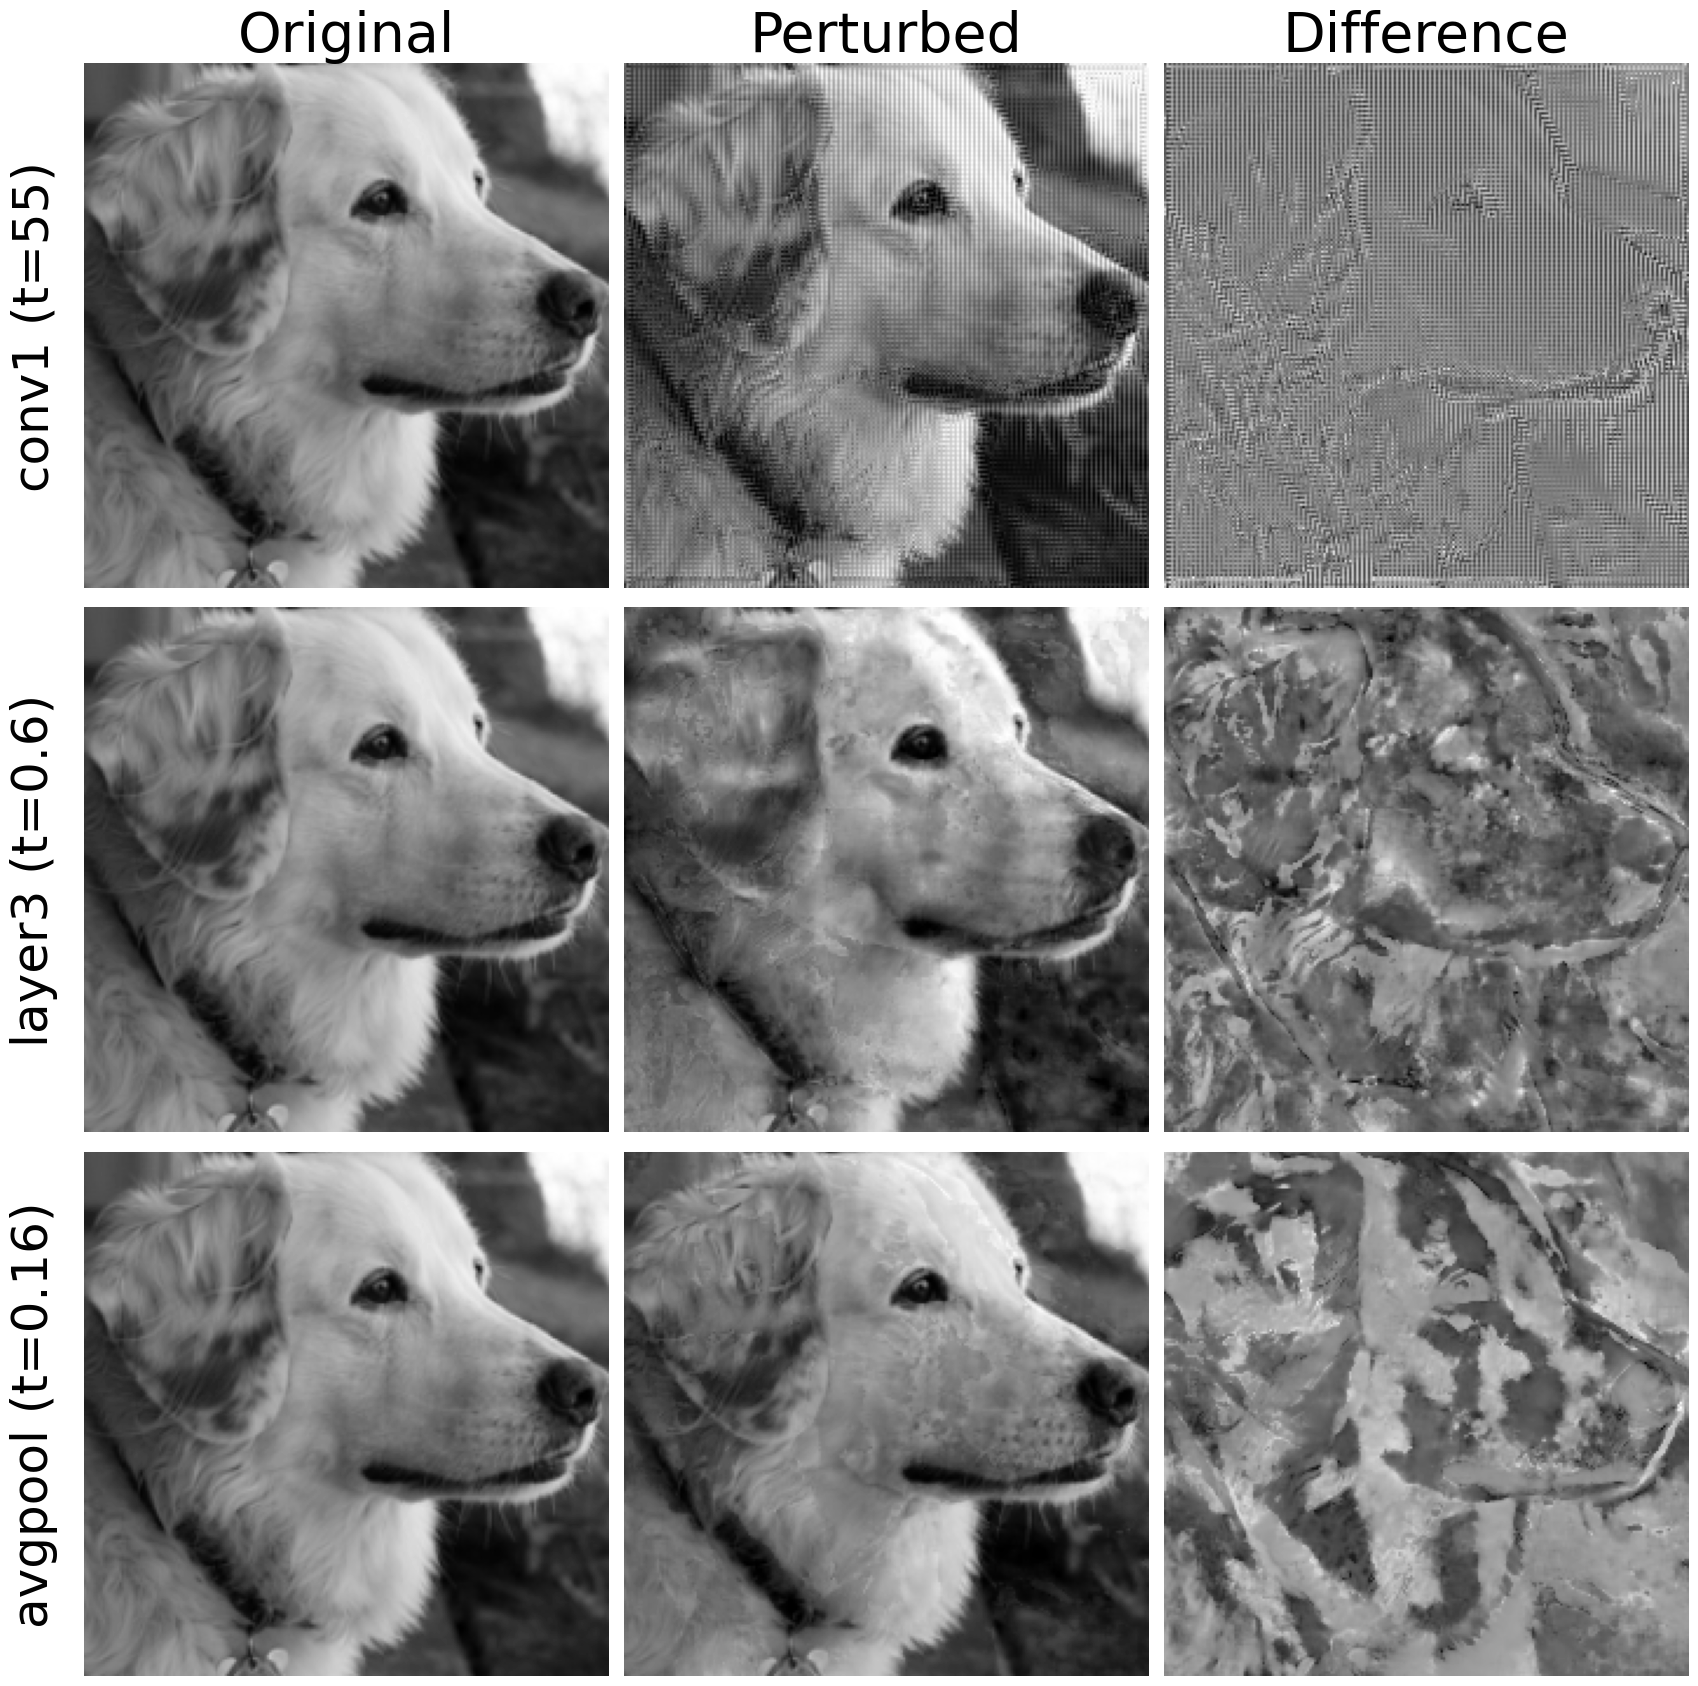

In [34]:
layers_and_thresholds = {
    "conv1": 55,
    "layer3": 0.6,
    "avgpool": 0.16,
}

generated_results = generate_images(layers_and_thresholds, model, device, transform)
plot_combined_diff_images(generated_results)

## RMS contrast

In [64]:
def compute_rms_contrast(image):
    """Calculate RMS contrast of a grayscale image."""
    return np.std(image)

print(compute_rms_contrast(orig_gray))

0.2128331743104199


In [ ]:
NUM_IMAGES = 30 #sample images

# experimental results
ecc_values = [4, 8, 12]
thresholds = {
    layer: [subject_thresholds[layer][ecc] for ecc in ecc_values]
    for layer in subject_thresholds
}

data_loader = prepare_data_from_pool(NUM_IMAGES, transform, device, seed=42) # random images 

In [ ]:
def generate_and_calculate_rms(cond_layer, threshold, ecc, model, device, transform, num_images=30, seed=42):
    random.seed(seed)
    cond = Condition(
        ecc=ecc,
        mode="ica",
        layer=cond_layer,
        component=0,
        direction="plus",
    )
    components = [0, 1, 2]
    directions = ["plus", "minus"]
    conds = [
        Condition(
            ecc=ecc,
            mode="ica",
            layer=cond_layer,
            component=random.choice(components),
            direction=random.choice(directions),
        )
        for _ in range(num_images)
    ]

    handler = cond.get_decomposition_handler()
    params_loader = AttackParamsLoader()
    attack_params = params_loader.get_attack_params(cond, threshold)
    data_loader = prepare_data_from_pool(num_images, transform, device, seed=seed)
    values = [threshold] * num_images

    results = generate_image_from_condition(
        attack_params=attack_params,
        cond=cond,
        model=model,
        device=device,
        data_loader_origin=data_loader,
        handler=handler,
        conds=conds,
        values=values,
        layer1_name="conv1",
    )

    rms_values = []
    for result in results:
        orig_img = np.clip(result.original_image[0].squeeze().transpose((1, 2, 0)), 0, 1)  # type: ignore
        fake_img = np.clip(
            result.perturbed_images[-1].squeeze().transpose((1, 2, 0)),  # type: ignore
            0,
            1,
        )  # type: ignore
        orig_gray = rgb_to_grayscale(orig_img)
        fake_gray = rgb_to_grayscale(fake_img)
        diff_img = orig_gray - fake_gray

        rms_contrast = np.std(diff_img)
        rms_values.append(rms_contrast)

    rms_mean = np.mean(rms_values)
    rms_std = np.std(rms_values)

    return rms_mean, rms_std



In [ ]:
import pandas as pd

selected_subjects = ["s00", "s01", "s02", "s03", "s04", "s05", "s06", "s07"] 
rms_records = []

for subject in selected_subjects:
    subject_thresholds = load_subject_thresholds(threshold_csv_path, subject)
    thresholds = {
        layer: [subject_thresholds[layer][ecc] for ecc in ecc_values]
        for layer in subject_thresholds
    }


    print("RMS Contrast Results:")
    for ecc_idx, ecc in enumerate(ecc_values):
        for layer in thresholds.keys():
            threshold = thresholds[layer][ecc_idx]
            rms_mean, rms_std = generate_and_calculate_rms(
                layer, threshold, ecc, model, device, transform, num_images=NUM_IMAGES
            )
            print(
                f"Layer: {layer}, ECC: {ecc}, Threshold: {threshold}, RMS Mean: {rms_mean:.4f}, RMS Std: {rms_std:.4f}"
            )

            rms_records.append(
                {
                    "Subject": subject,
                    "Layer": layer,
                    "Eccentricity": ecc,
                    "Threshold": threshold,
                    "RMS Mean": rms_mean,
                    "RMS Std": rms_std,
                }
            )

rms_df = pd.DataFrame(rms_records)
rms_df.to_csv("output/ana/rms_contrast_results_jupyter.csv", index=False)
display(rms_df)
        

0.09085207223269562
0.021503091694586786


In [ ]:
# Calculate the across-subject mean and standard error
rms_summary = (
    rms_df.groupby(["Layer", "Eccentricity"])["RMS Mean"]
    .agg(["mean", "std", "count"])
    .reset_index()
)
rms_summary["sem"] = rms_summary["std"] / np.sqrt(rms_summary["count"])

# plot rms (fig6.b)
fig, ax = plt.subplots(figsize=(10, 6))
layer_colors = {"conv1": "red", "layer3": "blue", "avgpool": "green"}
markers = {4: "o", 8: "s", 12: "^"}
x_positions = {"conv1": 1, "layer3": 2, "avgpool": 3}
x_labels = ["conv1", "layer3", "avgpool"]
ecc_shifts = {4: -0.06, 8: 0.0, 12: 0.06}

for _, row in rms_summary.iterrows():
    layer = row["Layer"]
    ecc = row["Eccentricity"]
    x = x_positions[layer] + ecc_shifts[ecc]
    y = row["mean"]
    error = row["sem"]

    ax.errorbar(
        x,
        y,
        yerr=error,
        color=layer_colors[layer],
        marker=markers[ecc],
        markersize=12,
        linestyle="--",
        capsize=6,
    )

ax.set_xticks(list(x_positions.values()))
ax.set_xticklabels(x_labels, fontsize=32)
ax.set_ylabel("RMS Contrast", fontsize=36)
ax.tick_params(axis="both", which="major", labelsize=32)
ax.grid(True)

legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="black", markersize=15, label="Ecc=4"),
    Line2D([0], [0], marker="s", color="w", markerfacecolor="black", markersize=15, label="Ecc=8"),
    Line2D([0], [0], marker="^", color="w", markerfacecolor="black", markersize=15, label="Ecc=12"),
]
ax.legend(handles=legend_elements, fontsize=28, loc="upper right")

plt.tight_layout()
plt.savefig("output/ana/rms_contrast_jupyter.png")
plt.show()

RMS Contrast Results:
Layer: conv1, ECC: 4, Threshold: 47.915, RMS Mean: 0.0919, RMS Std: 0.0240
Layer: layer3, ECC: 4, Threshold: 0.486, RMS Mean: 0.0356, RMS Std: 0.0078
Layer: avgpool, ECC: 4, Threshold: 0.1538, RMS Mean: 0.0401, RMS Std: 0.0120
Layer: conv1, ECC: 8, Threshold: 63.0404, RMS Mean: 0.1130, RMS Std: 0.0305
Layer: layer3, ECC: 8, Threshold: 0.5983, RMS Mean: 0.0495, RMS Std: 0.0102
Layer: avgpool, ECC: 8, Threshold: 0.153, RMS Mean: 0.0398, RMS Std: 0.0119
Layer: conv1, ECC: 12, Threshold: 63.7918, RMS Mean: 0.1140, RMS Std: 0.0308
Layer: layer3, ECC: 12, Threshold: 0.6407, RMS Mean: 0.0551, RMS Std: 0.0111
Layer: avgpool, ECC: 12, Threshold: 0.1688, RMS Mean: 0.0440, RMS Std: 0.0130


## SSIM・LPIPS・DISTS

In [ ]:

def _to_image_tensor(image, device):
    if image.ndim == 2:
        image = np.expand_dims(image, axis=-1)
    tensor = torch.from_numpy(np.clip(image, 0, 1).astype(np.float32)).permute(2, 0, 1).unsqueeze(0)
    return tensor.to(device)


def compute_ssim(image1, image2):
    img1 = np.clip(image1, 0, 1).astype(np.float32)
    img2 = np.clip(image2, 0, 1).astype(np.float32)
    return float(structural_similarity(img1, img2, data_range=1.0))



def compute_lpips(image1, image2, device, lpips_model):
    img1_tensor = _to_image_tensor(image1, device) * 2 - 1
    img2_tensor = _to_image_tensor(image2, device) * 2 - 1
    return float(lpips_model(img1_tensor, img2_tensor).item())


def compute_dists(image1, image2, device, dists_model):
    img1_tensor = _to_image_tensor(image1, device)
    img2_tensor = _to_image_tensor(image2, device)

    if img1_tensor.shape[1] == 1:
        img1_tensor = img1_tensor.repeat(1, 3, 1, 1)
    if img2_tensor.shape[1] == 1:
        img2_tensor = img2_tensor.repeat(1, 3, 1, 1)

    return float(dists_model(img1_tensor, img2_tensor).item())


def get_metric_function(metric, device):
    metric_name = metric.lower()

    if metric_name == "ssim":
        return compute_ssim


    if metric_name == "lpips":
        import lpips

        lpips_model = lpips.LPIPS(net="alex").to(device)
        lpips_model.eval()
        return lambda image1, image2: compute_lpips(image1, image2, device, lpips_model)

    if metric_name == "dists":
        from DISTS_pytorch import DISTS

        dists_model = DISTS().to(device)
        dists_model.eval()
        return lambda image1, image2: compute_dists(image1, image2, device, dists_model)

    raise ValueError(f"Unsupported metric: {metric}. Choose from 'ssim', 'ms-ssim', 'lpips', or 'dists'.")


def generate_and_calculate_metric(cond_layer, threshold, ecc, model, device, transform, metric="ssim", num_images=30, seed=42):
    random.seed(seed)
    cond = Condition(
        ecc=ecc,
        mode="ica",
        layer=cond_layer,
        component=0,
        direction="plus",
    )
    components = [0, 1, 2]
    directions = ["plus", "minus"]
    conds = [
        Condition(
            ecc=ecc,
            mode="ica",
            layer=cond_layer,
            component=random.choice(components),
            direction=random.choice(directions),
        )
        for _ in range(num_images)
    ]

    handler = cond.get_decomposition_handler()
    params_loader = AttackParamsLoader()
    attack_params = params_loader.get_attack_params(cond, threshold)
    data_loader = prepare_data_from_pool(num_images, transform, device, seed=seed)
    values = [threshold] * num_images

    results = generate_image_from_condition(
        attack_params=attack_params,
        cond=cond,
        model=model,
        device=device,
        data_loader_origin=data_loader,
        handler=handler,
        conds=conds,
        values=values,
        layer1_name="conv1",
    )

    metric_fn = get_metric_function(metric, device)
    metric_values = []
    for result in results:
        orig_img = np.clip(result.original_image[0].squeeze().transpose((1, 2, 0)), 0, 1)  # type: ignore
        fake_img = np.clip(
            result.perturbed_images[-1].squeeze().transpose((1, 2, 0)),  # type: ignore
            0,
            1,
        )  # type: ignore
        if metric.lower() in "ssim":
            orig_metric_img = rgb_to_grayscale(orig_img)
            fake_metric_img = rgb_to_grayscale(fake_img)
        else:
            orig_metric_img = orig_img
            fake_metric_img = fake_img

        metric_value = metric_fn(orig_metric_img, fake_metric_img)
        metric_values.append(metric_value)

    metric_mean = np.mean(metric_values)
    metric_std = np.std(metric_values)

    return metric_mean, metric_std


SSIM Results:
Layer: conv1, ECC: 4, Threshold: 47.915, SSIM Mean: 0.3926, SSIM Std: 0.1382
Layer: layer3, ECC: 4, Threshold: 0.486, SSIM Mean: 0.8539, SSIM Std: 0.0673
Layer: avgpool, ECC: 4, Threshold: 0.1538, SSIM Mean: 0.8635, SSIM Std: 0.0691
Layer: conv1, ECC: 8, Threshold: 63.0404, SSIM Mean: 0.3238, SSIM Std: 0.1269
Layer: layer3, ECC: 8, Threshold: 0.5983, SSIM Mean: 0.7697, SSIM Std: 0.0877
Layer: avgpool, ECC: 8, Threshold: 0.153, SSIM Mean: 0.8642, SSIM Std: 0.0690
Layer: conv1, ECC: 12, Threshold: 63.7918, SSIM Mean: 0.3211, SSIM Std: 0.1263
Layer: layer3, ECC: 12, Threshold: 0.6407, SSIM Mean: 0.7354, SSIM Std: 0.0939
Layer: avgpool, ECC: 12, Threshold: 0.1688, SSIM Mean: 0.8450, SSIM Std: 0.0742


### SSIM

In [ ]:
selected_subjects = ["s00", "s01", "s02", "s03", "s04", "s05", "s06", "s07"] 
ssim_records = []

for subject in selected_subjects:
    subject_thresholds = load_subject_thresholds(threshold_csv_path, subject)
    thresholds = {
        layer: [subject_thresholds[layer][ecc] for ecc in ecc_values]
        for layer in subject_thresholds
    }

    METRIC = "ssim"

    print(f"{METRIC.upper()} Results:")
    for ecc_idx, ecc in enumerate(ecc_values):
        for layer in thresholds.keys():
            threshold = thresholds[layer][ecc_idx]
            metric_mean, metric_std = generate_and_calculate_metric(
                layer, threshold, ecc, model, device, transform, metric=METRIC, num_images=NUM_IMAGES
            )
            print(
                f"Layer: {layer}, ECC: {ecc}, Threshold: {threshold}, {METRIC.upper()} Mean: {metric_mean:.4f}, {METRIC.upper()} Std: {metric_std:.4f}"
            )

            ssim_records.append(
                    {
                        "Subject": subject,
                        "Layer": layer,
                        "Eccentricity": ecc,
                        "Threshold": threshold,
                        "SSIM Mean": metric_mean,
                        "SSIM Std": metric_std,
                    }
            )

ssim_df = pd.DataFrame(ssim_records)
ssim_df.to_csv("output/ana/ssim_results_jupyter.csv", index=False)
display(ssim_df)

In [ ]:
ssim_summary = (
    ssim_df.groupby(["Layer", "Eccentricity"])["SSIM Mean"]
    .agg(["mean", "std", "count"])
    .reset_index()
)
ssim_summary["sem"] = ssim_summary["std"] / np.sqrt(ssim_summary["count"])

# plot rms (fig6.b)
fig, ax = plt.subplots(figsize=(10, 6))
layer_colors = {"conv1": "red", "layer3": "blue", "avgpool": "green"}
markers = {4: "o", 8: "s", 12: "^"}
x_positions = {"conv1": 1, "layer3": 2, "avgpool": 3}
x_labels = ["conv1", "layer3", "avgpool"]
ecc_shifts = {4: -0.06, 8: 0.0, 12: 0.06}

for _, row in ssim_summary.iterrows():
    layer = row["Layer"]
    ecc = row["Eccentricity"]
    x = x_positions[layer] + ecc_shifts[ecc]
    y = row["mean"]
    error = row["sem"]

    ax.errorbar(
        x,
        y,
        yerr=error,
        color=layer_colors[layer],
        marker=markers[ecc],
        markersize=12,
        linestyle="--",
        capsize=6,
    )

ax.set_xticks(list(x_positions.values()))
ax.set_xticklabels(x_labels, fontsize=32)
ax.set_ylabel("SSIM", fontsize=36)
ax.tick_params(axis="both", which="major", labelsize=32)
ax.grid(True)

legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="black", markersize=15, label="Ecc=4"),
    Line2D([0], [0], marker="s", color="w", markerfacecolor="black", markersize=15, label="Ecc=8"),
    Line2D([0], [0], marker="^", color="w", markerfacecolor="black", markersize=15, label="Ecc=12"),
]
ax.legend(handles=legend_elements, fontsize=28, loc="upper left")

plt.tight_layout()
plt.savefig("output/ana/rms_contrast_jupyter.png")
plt.show()

### LPIPS

In [ ]:
selected_subjects = ["s00", "s01", "s02", "s03", "s04", "s05", "s06", "s07"] 
lpips_records = []

for subject in selected_subjects:
    subject_thresholds = load_subject_thresholds(threshold_csv_path, subject)
    thresholds = {
        layer: [subject_thresholds[layer][ecc] for ecc in ecc_values]
        for layer in subject_thresholds
    }

    METRIC = "lpips"

    print(f"{METRIC.upper()} Results:")
    for ecc_idx, ecc in enumerate(ecc_values):
        for layer in thresholds.keys():
            threshold = thresholds[layer][ecc_idx]
            metric_mean, metric_std = generate_and_calculate_metric(
                layer, threshold, ecc, model, device, transform, metric=METRIC, num_images=NUM_IMAGES
            )
            print(
                f"Layer: {layer}, ECC: {ecc}, Threshold: {threshold}, {METRIC.upper()} Mean: {metric_mean:.4f}, {METRIC.upper()} Std: {metric_std:.4f}"
            )

            lpips_records.append(
                    {
                        "Subject": subject,
                        "Layer": layer,
                        "Eccentricity": ecc,
                        "Threshold": threshold,
                        "LPIPS Mean": metric_mean,
                        "LPIPS Std": metric_std,
                    }
            )

lpips_df = pd.DataFrame(lpips_records)
lpips_df.to_csv("output/ana/lpips_results_jupyter.csv", index=False)
display(lpips_df)

In [ ]:
lpips_summary = (
    lpips_df.groupby(["Layer", "Eccentricity"])["LPIPS Mean"]
    .agg(["mean", "std", "count"])
    .reset_index()
)
lpips_summary["sem"] = lpips_summary["std"] / np.sqrt(lpips_summary["count"])

# plot rms (fig6.b)
fig, ax = plt.subplots(figsize=(10, 6))
layer_colors = {"conv1": "red", "layer3": "blue", "avgpool": "green"}
markers = {4: "o", 8: "s", 12: "^"}
x_positions = {"conv1": 1, "layer3": 2, "avgpool": 3}
x_labels = ["conv1", "layer3", "avgpool"]
ecc_shifts = {4: -0.06, 8: 0.0, 12: 0.06}

for _, row in lpips_summary.iterrows():
    layer = row["Layer"]
    ecc = row["Eccentricity"]
    x = x_positions[layer] + ecc_shifts[ecc]
    y = row["mean"]
    error = row["sem"]

    ax.errorbar(
        x,
        y,
        yerr=error,
        color=layer_colors[layer],
        marker=markers[ecc],
        markersize=12,
        linestyle="--",
        capsize=6,
    )

ax.set_xticks(list(x_positions.values()))
ax.set_xticklabels(x_labels, fontsize=32)
ax.set_ylabel("LPIPS", fontsize=36)
ax.tick_params(axis="both", which="major", labelsize=32)
ax.grid(True)

legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="black", markersize=15, label="Ecc=4"),
    Line2D([0], [0], marker="s", color="w", markerfacecolor="black", markersize=15, label="Ecc=8"),
    Line2D([0], [0], marker="^", color="w", markerfacecolor="black", markersize=15, label="Ecc=12"),
]
ax.legend(handles=legend_elements, fontsize=28, loc="upper right")

plt.tight_layout()
plt.savefig("output/ana/rms_contrast_jupyter.png")
plt.show()

### DISTS

In [ ]:
selected_subjects = ["s00", "s01", "s02", "s03", "s04", "s05", "s06", "s07"] 
dists_records = []

for subject in selected_subjects:
    subject_thresholds = load_subject_thresholds(threshold_csv_path, subject)
    thresholds = {
        layer: [subject_thresholds[layer][ecc] for ecc in ecc_values]
        for layer in subject_thresholds
    }

    METRIC = "dists"

    print(f"{METRIC.upper()} Results:")
    for ecc_idx, ecc in enumerate(ecc_values):
        for layer in thresholds.keys():
            threshold = thresholds[layer][ecc_idx]
            metric_mean, metric_std = generate_and_calculate_metric(
                layer, threshold, ecc, model, device, transform, metric=METRIC, num_images=NUM_IMAGES
            )
            print(
                f"Layer: {layer}, ECC: {ecc}, Threshold: {threshold}, {METRIC.upper()} Mean: {metric_mean:.4f}, {METRIC.upper()} Std: {metric_std:.4f}"
            )

            dists_records.append(
                    {
                        "Subject": subject,
                        "Layer": layer,
                        "Eccentricity": ecc,
                        "Threshold": threshold,
                        "DISTS Mean": metric_mean,
                        "DISTS Std": metric_std,
                    }
            )

dists_df = pd.DataFrame(dists_records)
dists_df.to_csv("output/ana/dists_results_jupyter.csv", index=False)
display(dists_df)

In [ ]:
dists_summary = (
    dists_df.groupby(["Layer", "Eccentricity"])["DISTS Mean"]
    .agg(["mean", "std", "count"])
    .reset_index()
)
dists_summary["sem"] = dists_summary["std"] / np.sqrt(dists_summary["count"])

# plot rms (fig6.b)
fig, ax = plt.subplots(figsize=(10, 6))
layer_colors = {"conv1": "red", "layer3": "blue", "avgpool": "green"}
markers = {4: "o", 8: "s", 12: "^"}
x_positions = {"conv1": 1, "layer3": 2, "avgpool": 3}
x_labels = ["conv1", "layer3", "avgpool"]
ecc_shifts = {4: -0.06, 8: 0.0, 12: 0.06}

for _, row in dists_summary.iterrows():
    layer = row["Layer"]
    ecc = row["Eccentricity"]
    x = x_positions[layer] + ecc_shifts[ecc]
    y = row["mean"]
    error = row["sem"]

    ax.errorbar(
        x,
        y,
        yerr=error,
        color=layer_colors[layer],
        marker=markers[ecc],
        markersize=12,
        linestyle="--",
        capsize=6,
    )

ax.set_xticks(list(x_positions.values()))
ax.set_xticklabels(x_labels, fontsize=32)
ax.set_ylabel("DISTS", fontsize=36)
ax.tick_params(axis="both", which="major", labelsize=32)
ax.grid(True)

legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="black", markersize=15, label="Ecc=4"),
    Line2D([0], [0], marker="s", color="w", markerfacecolor="black", markersize=15, label="Ecc=8"),
    Line2D([0], [0], marker="^", color="w", markerfacecolor="black", markersize=15, label="Ecc=12"),
]
ax.legend(handles=legend_elements, fontsize=28, loc="upper right")

plt.tight_layout()
plt.savefig("output/ana/rms_contrast_jupyter.png")
plt.show()